In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    print(filenames[:5])


/kaggle/input
[]
/kaggle/input/brats20-dataset-training-validation
[]
/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData
[]
/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData
['name_mapping_validation_data.csv', 'survival_evaluation.csv']
/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_084
['BraTS20_Validation_084_flair.nii', 'BraTS20_Validation_084_t2.nii', 'BraTS20_Validation_084_t1ce.nii', 'BraTS20_Validation_084_t1.nii']
/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_118
['BraTS20_Validation_118_t2.nii', 'BraTS20_Validation_118_t1.nii', 'BraTS20_Validation_118_t1ce.nii', 'BraTS20_Validation_118_flair.nii']
/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_111
['BraTS20_Valid

## Install Required Libraries

In [2]:
!pip install nibabel -q
!pip install SimpleITK -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import nibabel as nib
from sklearn.cluster import KMeans
from scipy import ndimage
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Dataset Path Configuration & Exploration


In [4]:
# Dataset paths
DATASET_ROOT = '/kaggle/input/brats20-dataset-training-validation'
TRAINING_ROOT = f'{DATASET_ROOT}/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
VALIDATION_ROOT = f'{DATASET_ROOT}/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData'

# Get patient directories
training_dirs = sorted([d for d in Path(TRAINING_ROOT).iterdir() if d.is_dir()])
validation_dirs = sorted([d for d in Path(VALIDATION_ROOT).iterdir() if d.is_dir()])

print(f"{'='*70}")
print(f"BraTS2020 DATASET SUMMARY")
print(f"{'='*70}")
print(f"Training Patients:   {len(training_dirs)}")
print(f"Validation Patients: {len(validation_dirs)}")
print(f"Total Patients:      {len(training_dirs) + len(validation_dirs)}")
print(f"{'='*70}\n")

# Display first 5 training patients
print("First 5 Training Patients:")
for i, patient_dir in enumerate(training_dirs[:5], 1):
    files = list(patient_dir.glob('*.nii'))
    print(f"  {i}. {patient_dir.name:<30} ({len(files)} files)")

# Check file types in first patient
first_patient = training_dirs[0]
print(f"\nFiles in {first_patient.name}:")
for file in sorted(first_patient.glob('*.nii')):
    file_size = file.stat().st_size / (1024*1024)  # MB
    print(f"  • {file.name:<40} ({file_size:.1f} MB)")

BraTS2020 DATASET SUMMARY
Training Patients:   369
Validation Patients: 125
Total Patients:      494

First 5 Training Patients:
  1. BraTS20_Training_001           (5 files)
  2. BraTS20_Training_002           (5 files)
  3. BraTS20_Training_003           (5 files)
  4. BraTS20_Training_004           (5 files)
  5. BraTS20_Training_005           (5 files)

Files in BraTS20_Training_001:
  • BraTS20_Training_001_flair.nii           (17.0 MB)
  • BraTS20_Training_001_seg.nii             (8.5 MB)
  • BraTS20_Training_001_t1.nii              (17.0 MB)
  • BraTS20_Training_001_t1ce.nii            (17.0 MB)
  • BraTS20_Training_001_t2.nii              (17.0 MB)


### Visualize Sample Patient Data


Visualizing first training patient...


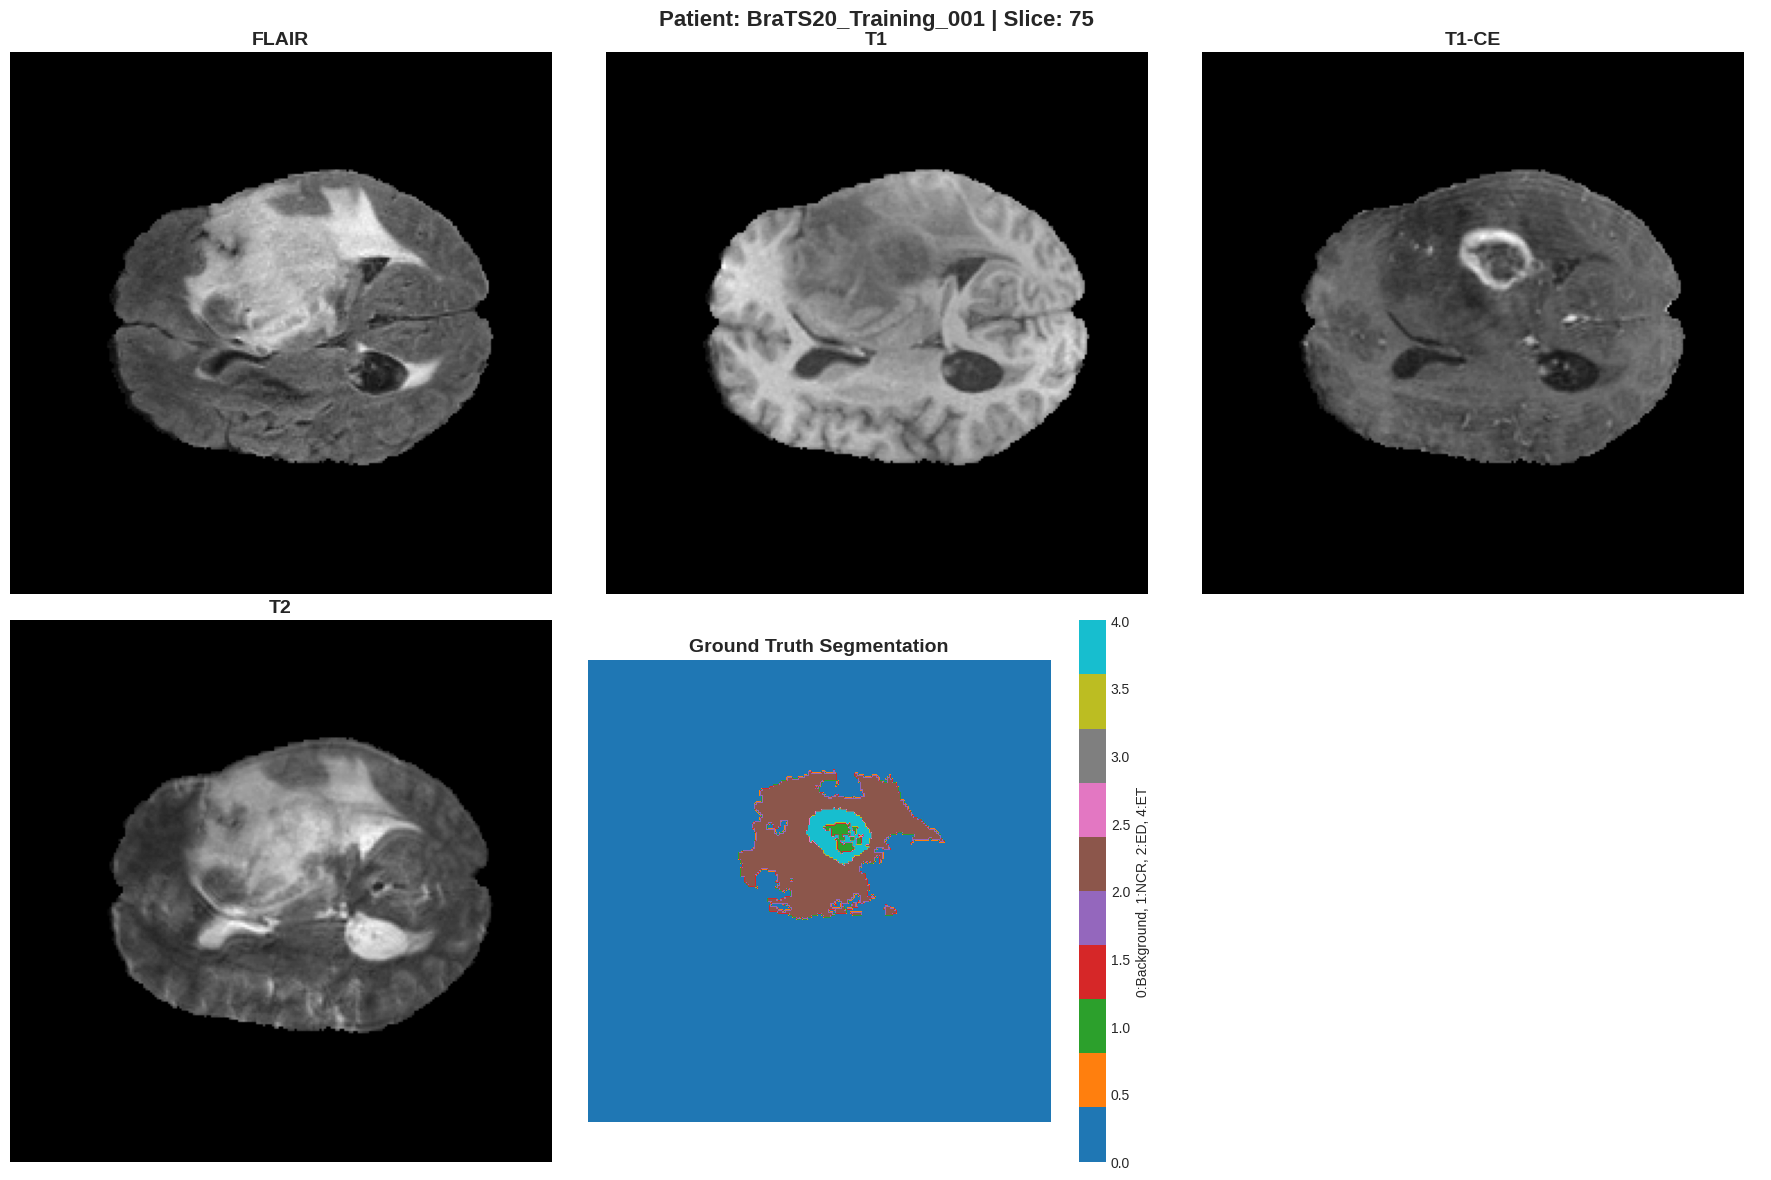

In [5]:
def visualize_patient_modalities(patient_dir, slice_idx=None):
    """Visualize all 4 modalities + segmentation for a patient"""
    patient_id = patient_dir.namei
    
    # Define modalities
    modalities = ['flair', 't1', 't1ce', 't2', 'seg']
    images = {}
    
    # Load each modality
    for mod in modalities:
        filepath = patient_dir / f"{patient_id}_{mod}.nii"
        if filepath.exists():
            img = nib.load(str(filepath))
            volume = img.get_fdata()
            
            # Get middle slice if not specified
            if slice_idx is None:
                # Find slice with most brain tissue
                slice_sums = [np.sum(volume[:, :, i] > 0) for i in range(volume.shape[2])]
                slice_idx = np.argmax(slice_sums)
            
            images[mod] = volume[:, :, slice_idx]
        else:
            images[mod] = None
    
    # Create visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Patient: {patient_id} | Slice: {slice_idx}', 
                 fontsize=16, fontweight='bold')
    
    # Plot modalities
    modality_names = {
        'flair': 'FLAIR',
        't1': 'T1',
        't1ce': 'T1-CE',
        't2': 'T2',
        'seg': 'Ground Truth Segmentation'
    }
    
    positions = [(0,0), (0,1), (0,2), (1,0), (1,1)]
    
    for idx, (mod, name) in enumerate(modality_names.items()):
        if idx < len(positions):
            row, col = positions[idx]
            
            if images[mod] is not None:
                if mod == 'seg':
                    # Use discrete colormap for segmentation
                    im = axes[row, col].imshow(images[mod], cmap='tab10', vmin=0, vmax=4)
                    plt.colorbar(im, ax=axes[row, col], 
                               label='0:Background, 1:NCR, 2:ED, 4:ET')
                else:
                    axes[row, col].imshow(images[mod], cmap='gray')
                
                axes[row, col].set_title(name, fontsize=14, fontweight='bold')
                axes[row, col].axis('off')
            else:
                axes[row, col].text(0.5, 0.5, f'{name}\nNot Available', 
                                   ha='center', va='center', fontsize=12)
                axes[row, col].axis('off')
    
    # Hide last subplot
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return images, slice_idx

# Visualize first patient
print("\nVisualizing first training patient...")
images, slice_idx = visualize_patient_modalities(training_dirs[0])

## Wu et al. (2007) K-means Segmentation Class

In [6]:
class WuKMeansBraTSSegmentation:
    """
    Implementation of Wu et al. (2007) K-means clustering method
    Paper: "Brain Tumor Detection Using Color-Based K-Means Clustering Segmentation"
    Adapted for grayscale MRI from BraTS2020 dataset
    """
    
    def __init__(self, n_clusters=10, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        
    def load_nifti_slice(self, filepath, slice_idx=None):
        """Load a 2D slice from NIfTI file"""
        img = nib.load(str(filepath))
        volume = img.get_fdata()
        
        if slice_idx is None:
            # Find slice with most non-zero voxels
            slice_sums = [np.sum(volume[:, :, i] > 0) for i in range(volume.shape[2])]
            slice_idx = np.argmax(slice_sums)
            
        slice_2d = volume[:, :, slice_idx]
        return slice_2d, slice_idx
    
    def normalize_image(self, image):
        """Normalize image to 0-255 range"""
        brain_mask = image > 0
        
        if np.sum(brain_mask) == 0:
            return image.astype(np.uint8)
        
        brain_pixels = image[brain_mask]
        p2, p98 = np.percentile(brain_pixels, (2, 98))
        
        image_clipped = np.clip(image, p2, p98)
        image_normalized = ((image_clipped - p2) / (p98 - p2) * 255).astype(np.uint8)
        
        return image_normalized
    
    def create_multi_channel_features(self, gray_image):
        """
        Create multi-channel features from grayscale MRI
        Adapts Wu's L*a*b* color features to grayscale
        """
        # Feature 1: Intensity
        f1 = gray_image.astype(np.float32)
        
        # Feature 2: Gradient magnitude (edges)
        gx = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=3)
        f2 = np.sqrt(gx**2 + gy**2)
        f2 = ((f2 - f2.min()) / (f2.max() - f2.min() + 1e-8) * 255).astype(np.float32)
        
        # Feature 3: Texture (Laplacian)
        f3 = cv2.Laplacian(gray_image, cv2.CV_64F)
        f3 = np.abs(f3)
        f3 = ((f3 - f3.min()) / (f3.max() - f3.min() + 1e-8) * 255).astype(np.float32)
        
        features = np.dstack([f1, f2, f3])
        return features
    
    def apply_kmeans(self, image, features):
        """Apply K-means clustering"""
        brain_mask = image > 0
        h, w, c = features.shape
        feature_vectors = features.reshape(-1, c)
        
        brain_indices = np.where(brain_mask.flatten())[0]
        brain_features = feature_vectors[brain_indices]
        
        # K-means clustering
        kmeans = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            n_init=10,
            max_iter=300
        )
        brain_labels = kmeans.fit_predict(brain_features)
        
        labels = np.zeros(h * w, dtype=np.int32)
        labels[brain_indices] = brain_labels
        labels = labels.reshape(h, w)
        
        return labels, kmeans.cluster_centers_
    
    def identify_tumor_clusters(self, image, labels):
        """Identify clusters likely to contain tumor"""
        cluster_stats = []
        
        for i in range(self.n_clusters):
            cluster_mask = (labels == i)
            cluster_pixels = image[cluster_mask]
            
            if len(cluster_pixels) > 0:
                stats = {
                    'cluster_id': i,
                    'size': len(cluster_pixels),
                    'mean_intensity': np.mean(cluster_pixels),
                    'std_intensity': np.std(cluster_pixels),
                    'size_ratio': len(cluster_pixels) / np.sum(image > 0)
                }
            else:
                stats = {
                    'cluster_id': i,
                    'size': 0,
                    'mean_intensity': 0,
                    'std_intensity': 0,
                    'size_ratio': 0
                }
            cluster_stats.append(stats)
        
        # Score clusters (tumor typically: moderate size, higher intensity)
        for stats in cluster_stats:
            size_score = 1.0 if (0.01 < stats['size_ratio'] < 0.3) else 0.5
            intensity_score = stats['mean_intensity'] / 255.0
            stats['score'] = size_score * intensity_score
        
        # Select top 2-3 clusters as tumor candidates
        sorted_clusters = sorted(cluster_stats, key=lambda x: x['score'], reverse=True)
        tumor_cluster_ids = [c['cluster_id'] for c in sorted_clusters[:3]]
        
        return tumor_cluster_ids, cluster_stats
    
    def extract_tumor_mask(self, labels, tumor_cluster_ids):
        """Extract tumor region with morphological cleanup"""
        tumor_mask = np.zeros_like(labels, dtype=bool)
        
        for cluster_id in tumor_cluster_ids:
            tumor_mask |= (labels == cluster_id)
        
        # Morphological operations
        tumor_mask = ndimage.binary_opening(tumor_mask, iterations=2)
        tumor_mask = ndimage.binary_closing(tumor_mask, iterations=2)
        
        return tumor_mask
    
    def segment_slice(self, filepath, slice_idx=None):
        """Complete segmentation pipeline for one slice"""
        # Load
        slice_2d, slice_idx = self.load_nifti_slice(filepath, slice_idx)
        
        # Normalize
        normalized = self.normalize_image(slice_2d)
        
        # Create features
        features = self.create_multi_channel_features(normalized)
        
        # K-means clustering
        labels, centers = self.apply_kmeans(normalized, features)
        
        # Identify tumor
        tumor_ids, cluster_stats = self.identify_tumor_clusters(normalized, labels)
        
        # Extract tumor mask
        tumor_mask = self.extract_tumor_mask(labels, tumor_ids)
        
        results = {
            'slice_idx': slice_idx,
            'original': slice_2d,
            'normalized': normalized,
            'features': features,
            'labels': labels,
            'tumor_mask': tumor_mask,
            'tumor_area': np.sum(tumor_mask),
            'cluster_stats': cluster_stats,
            'tumor_cluster_ids': tumor_ids
        }
        
        return results

print("✅ Wu et al. (2007) K-means segmentation class created!")

✅ Wu et al. (2007) K-means segmentation class created!


## Test Segmentation on Single Patient

In [7]:
# Initialize segmenter
segmenter = WuKMeansBraTSSegmentation(n_clusters=10)

# Select first patient
test_patient = training_dirs[0]
patient_id = test_patient.name
flair_path = test_patient / f"{patient_id}_flair.nii"

print(f"Testing segmentation on: {patient_id}")
print(f"Processing FLAIR image: {flair_path.name}")
print(f"\nRunning K-means clustering...")

# Run segmentation
results = segmenter.segment_slice(str(flair_path))

print(f"\n{'='*70}")
print(f"SEGMENTATION RESULTS")
print(f"{'='*70}")
print(f"Slice Index:       {results['slice_idx']}")
print(f"Tumor Area:        {results['tumor_area']:,} pixels")
print(f"Tumor Clusters:    {results['tumor_cluster_ids']}")
print(f"Number of Clusters: {segmenter.n_clusters}")
print(f"{'='*70}")

Testing segmentation on: BraTS20_Training_001
Processing FLAIR image: BraTS20_Training_001_flair.nii

Running K-means clustering...

SEGMENTATION RESULTS
Slice Index:       75
Tumor Area:        3,783 pixels
Tumor Clusters:    [4, 7, 9]
Number of Clusters: 10


## Visualize Segmentation Results

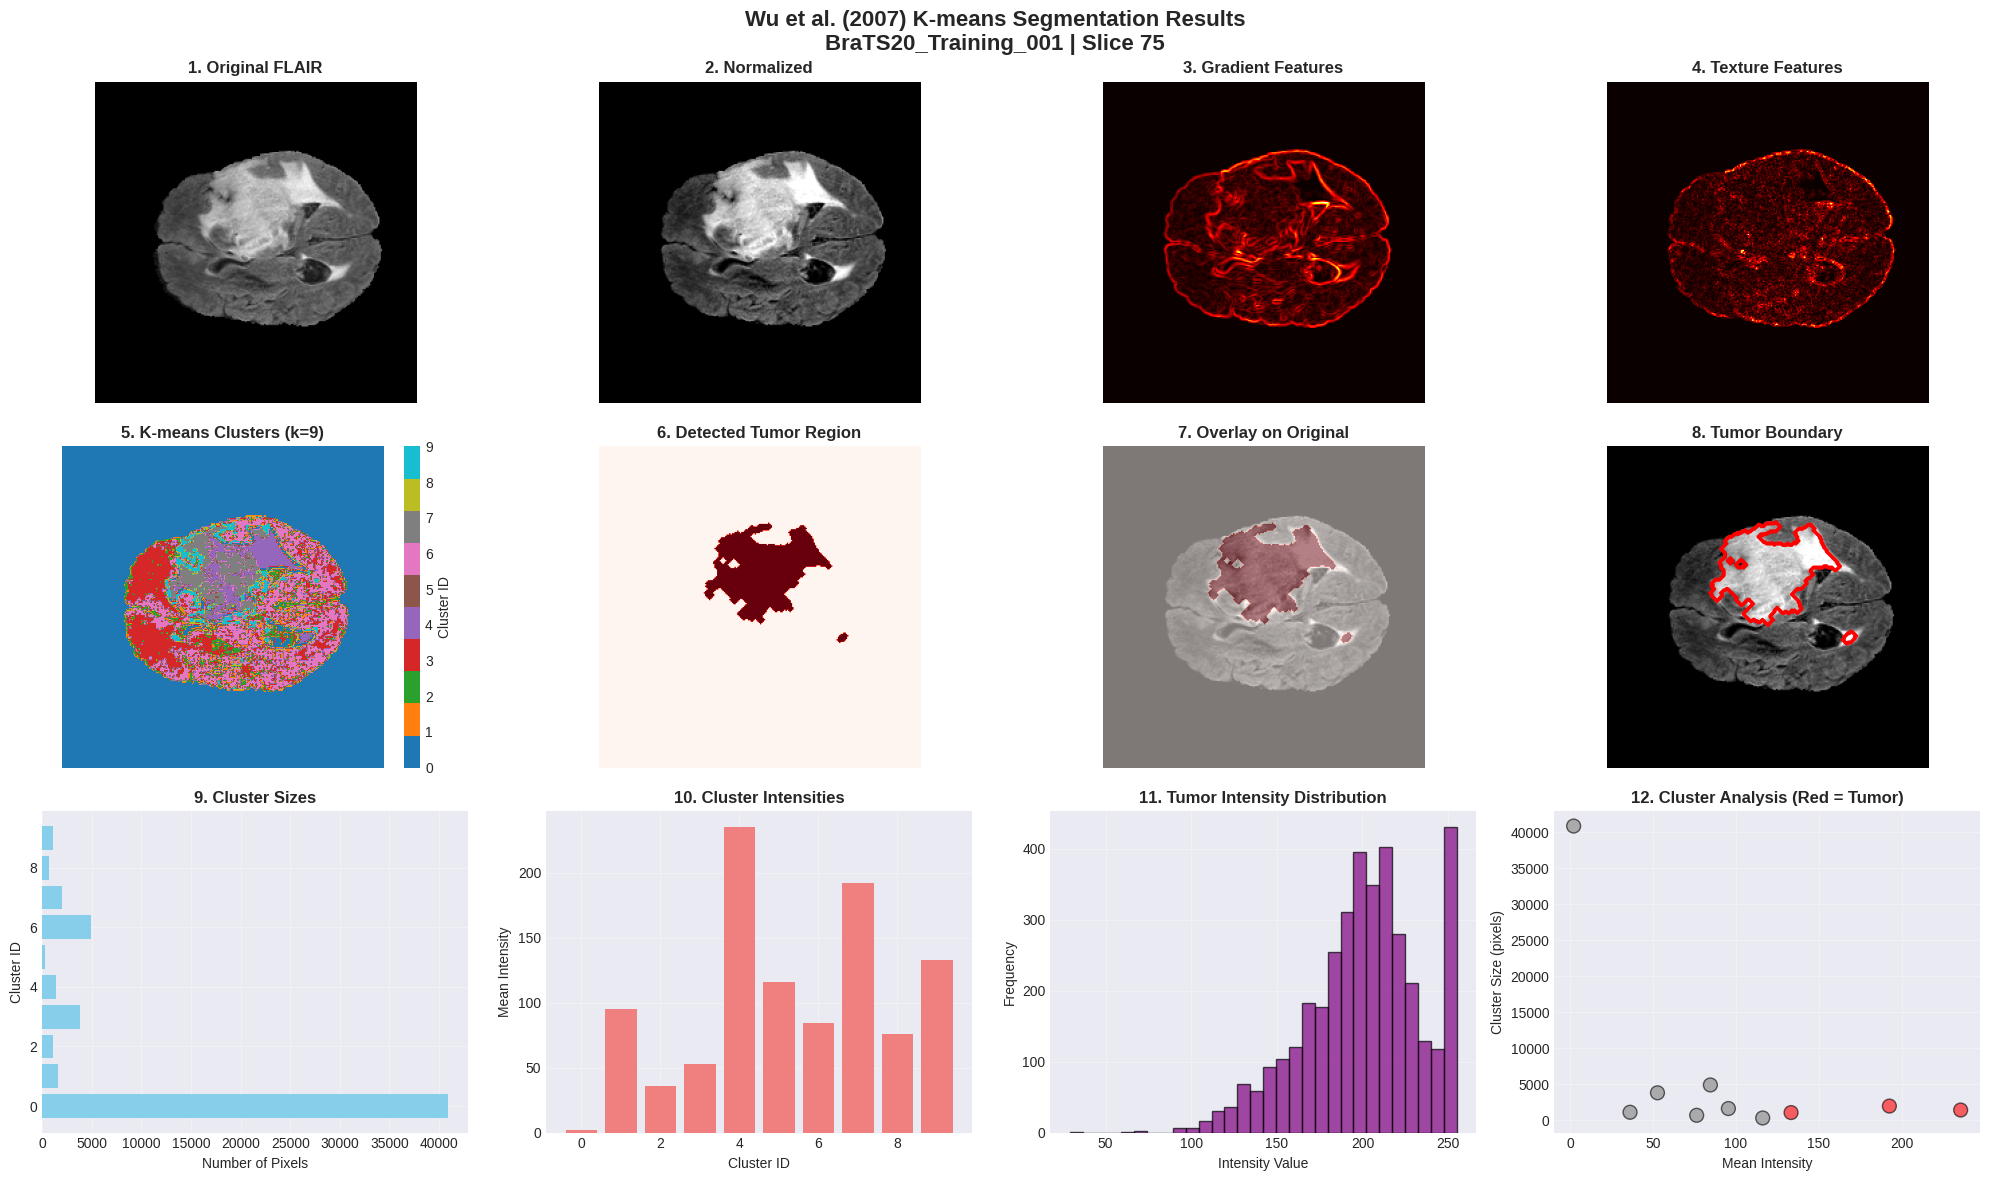

In [9]:
# ============================================================================
# CELL 7 (FIXED): Visualize Segmentation Results
# ============================================================================
from skimage.segmentation import find_boundaries  # Add this import

def visualize_segmentation_results(results, patient_id):
    """Comprehensive visualization of segmentation results"""
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f'Wu et al. (2007) K-means Segmentation Results\n{patient_id} | Slice {results["slice_idx"]}',
                 fontsize=16, fontweight='bold')
    
    # Row 1: Original processing steps
    ax1 = plt.subplot(3, 4, 1)
    ax1.imshow(results['original'], cmap='gray')
    ax1.set_title('1. Original FLAIR', fontweight='bold')
    ax1.axis('off')
    
    ax2 = plt.subplot(3, 4, 2)
    ax2.imshow(results['normalized'], cmap='gray')
    ax2.set_title('2. Normalized', fontweight='bold')
    ax2.axis('off')
    
    ax3 = plt.subplot(3, 4, 3)
    ax3.imshow(results['features'][:, :, 1], cmap='hot')
    ax3.set_title('3. Gradient Features', fontweight='bold')
    ax3.axis('off')
    
    ax4 = plt.subplot(3, 4, 4)
    ax4.imshow(results['features'][:, :, 2], cmap='hot')
    ax4.set_title('4. Texture Features', fontweight='bold')
    ax4.axis('off')
    
    # Row 2: Clustering results
    ax5 = plt.subplot(3, 4, 5)
    im5 = ax5.imshow(results['labels'], cmap='tab10')
    ax5.set_title(f'5. K-means Clusters (k={len(np.unique(results["labels"]))-1})', fontweight='bold')
    ax5.axis('off')
    plt.colorbar(im5, ax=ax5, label='Cluster ID')
    
    ax6 = plt.subplot(3, 4, 6)
    ax6.imshow(results['tumor_mask'], cmap='Reds')
    ax6.set_title('6. Detected Tumor Region', fontweight='bold')
    ax6.axis('off')
    
    ax7 = plt.subplot(3, 4, 7)
    ax7.imshow(results['normalized'], cmap='gray')
    ax7.imshow(results['tumor_mask'], cmap='Reds', alpha=0.5)
    ax7.set_title('7. Overlay on Original', fontweight='bold')
    ax7.axis('off')
    
    ax8 = plt.subplot(3, 4, 8)
    # Contour visualization - FIXED
    ax8.imshow(results['normalized'], cmap='gray')
    try:
        contours = find_boundaries(results['tumor_mask'], mode='outer')  # FIXED
        ax8.contour(contours, colors='red', linewidths=2)
    except:
        # Fallback: just show the mask if contour fails
        ax8.imshow(results['tumor_mask'], cmap='Reds', alpha=0.3)
    ax8.set_title('8. Tumor Boundary', fontweight='bold')
    ax8.axis('off')
    
    # Row 3: Statistics
    ax9 = plt.subplot(3, 4, 9)
    cluster_df = pd.DataFrame(results['cluster_stats'])
    cluster_df_sorted = cluster_df.sort_values('size', ascending=True)
    ax9.barh(cluster_df_sorted['cluster_id'], cluster_df_sorted['size'], color='skyblue')
    ax9.set_xlabel('Number of Pixels')
    ax9.set_ylabel('Cluster ID')
    ax9.set_title('9. Cluster Sizes', fontweight='bold')
    ax9.grid(True, alpha=0.3)
    
    ax10 = plt.subplot(3, 4, 10)
    ax10.bar(cluster_df['cluster_id'], cluster_df['mean_intensity'], color='lightcoral')
    ax10.set_xlabel('Cluster ID')
    ax10.set_ylabel('Mean Intensity')
    ax10.set_title('10. Cluster Intensities', fontweight='bold')
    ax10.grid(True, alpha=0.3)
    
    ax11 = plt.subplot(3, 4, 11)
    tumor_pixels = results['normalized'][results['tumor_mask']]
    if len(tumor_pixels) > 0:
        ax11.hist(tumor_pixels, bins=30, color='purple', alpha=0.7, edgecolor='black')
        ax11.set_xlabel('Intensity Value')
        ax11.set_ylabel('Frequency')
        ax11.set_title('11. Tumor Intensity Distribution', fontweight='bold')
        ax11.grid(True, alpha=0.3)
    
    ax12 = plt.subplot(3, 4, 12)
    # Highlight tumor clusters
    tumor_cluster_ids = results['tumor_cluster_ids']
    colors = ['red' if i in tumor_cluster_ids else 'gray' 
              for i in cluster_df['cluster_id']]
    ax12.scatter(cluster_df['mean_intensity'], cluster_df['size'], 
                c=colors, s=100, alpha=0.6, edgecolors='black')
    ax12.set_xlabel('Mean Intensity')
    ax12.set_ylabel('Cluster Size (pixels)')
    ax12.set_title('12. Cluster Analysis (Red = Tumor)', fontweight='bold')
    ax12.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize results
visualize_segmentation_results(results, patient_id)



Evaluating segmentation against ground truth...

EVALUATION METRICS
Dice Coefficient:  0.8866
IoU (Jaccard):     0.7963
Sensitivity:       0.8117
Specificity:       0.9983


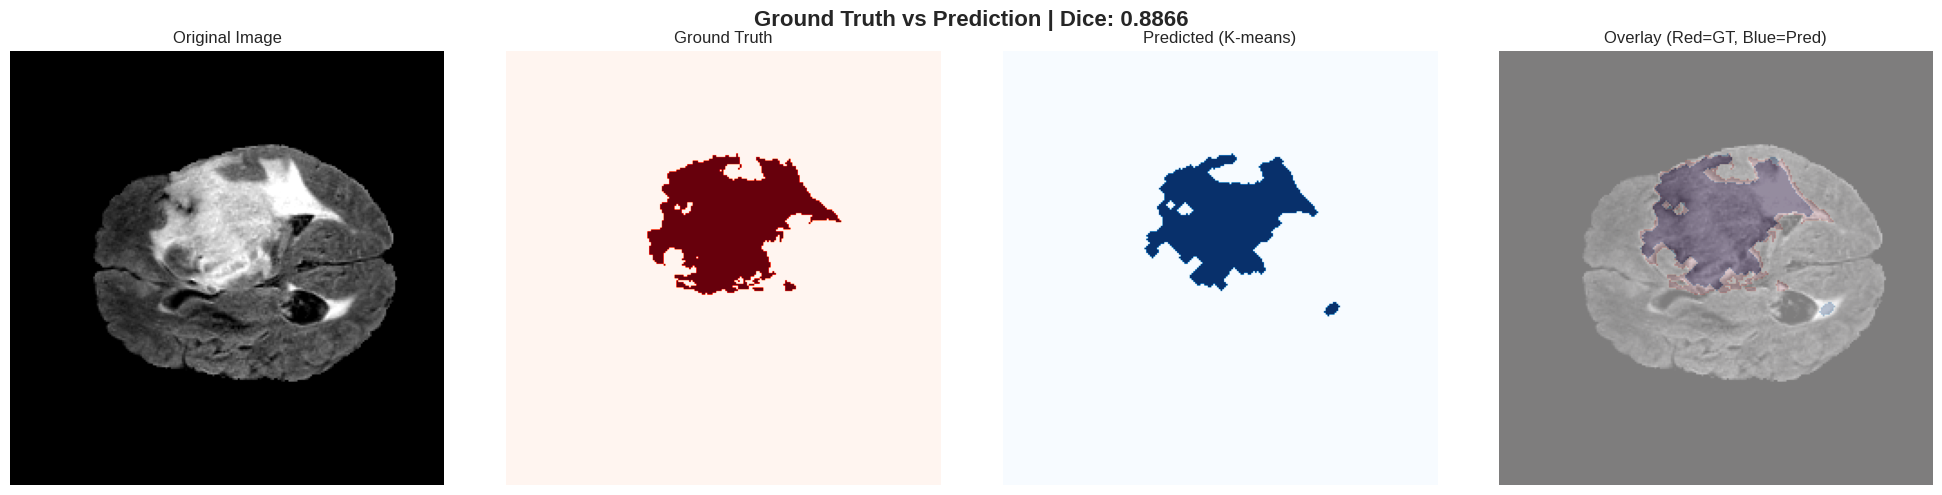

In [10]:
# ============================================================================
# CELL 8: Compare with Ground Truth
# ============================================================================
def calculate_dice_score(pred, gt):
    """Calculate Dice coefficient"""
    intersection = np.sum(pred * gt)
    if np.sum(pred) + np.sum(gt) == 0:
        return 1.0
    return 2.0 * intersection / (np.sum(pred) + np.sum(gt))

def evaluate_segmentation(patient_dir, results):
    """Evaluate segmentation against ground truth"""
    patient_id = patient_dir.name
    seg_path = patient_dir / f"{patient_id}_seg.nii"
    
    if not seg_path.exists():
        print("⚠️ Ground truth segmentation not available")
        return None
    
    # Load ground truth
    seg_img = nib.load(str(seg_path))
    seg_volume = seg_img.get_fdata()
    gt_slice = seg_volume[:, :, results['slice_idx']]
    
    # Create binary ground truth (any tumor class > 0)
    gt_binary = (gt_slice > 0).astype(int)
    pred_binary = results['tumor_mask'].astype(int)
    
    # Calculate metrics
    dice = calculate_dice_score(pred_binary, gt_binary)
    
    # Calculate IoU (Jaccard Index)
    intersection = np.sum(pred_binary * gt_binary)
    union = np.sum(pred_binary) + np.sum(gt_binary) - intersection
    iou = intersection / union if union > 0 else 0
    
    # Calculate sensitivity and specificity
    tp = np.sum(pred_binary * gt_binary)
    fp = np.sum(pred_binary * (1 - gt_binary))
    fn = np.sum((1 - pred_binary) * gt_binary)
    tn = np.sum((1 - pred_binary) * (1 - gt_binary))
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    metrics = {
        'dice': dice,
        'iou': iou,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'gt_slice': gt_slice,
        'gt_binary': gt_binary
    }
    
    return metrics

# Evaluate
print(f"\nEvaluating segmentation against ground truth...")
eval_results = evaluate_segmentation(test_patient, results)

if eval_results:
    print(f"\n{'='*70}")
    print(f"EVALUATION METRICS")
    print(f"{'='*70}")
    print(f"Dice Coefficient:  {eval_results['dice']:.4f}")
    print(f"IoU (Jaccard):     {eval_results['iou']:.4f}")
    print(f"Sensitivity:       {eval_results['sensitivity']:.4f}")
    print(f"Specificity:       {eval_results['specificity']:.4f}")
    print(f"{'='*70}")
    
    # Visualize comparison
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'Ground Truth vs Prediction | Dice: {eval_results["dice"]:.4f}',
                 fontsize=16, fontweight='bold')
    
    axes[0].imshow(results['normalized'], cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(eval_results['gt_binary'], cmap='Reds')
    axes[1].set_title('Ground Truth')
    axes[1].axis('off')
    
    axes[2].imshow(results['tumor_mask'], cmap='Blues')
    axes[2].set_title('Predicted (K-means)')
    axes[2].axis('off')
    
    # Overlay comparison
    axes[3].imshow(results['normalized'], cmap='gray')
    axes[3].imshow(eval_results['gt_binary'], cmap='Reds', alpha=0.3, label='Ground Truth')
    axes[3].imshow(results['tumor_mask'], cmap='Blues', alpha=0.3, label='Predicted')
    axes[3].set_title('Overlay (Red=GT, Blue=Pred)')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()

In [11]:
# ============================================================================
# CELL 9: Batch Process Multiple Patients
# ============================================================================
def batch_process_patients(patient_dirs, num_patients=20):
    """Process multiple patients and collect results"""
    segmenter = WuKMeansBraTSSegmentation(n_clusters=10)
    all_results = []
    
    for patient_dir in tqdm(patient_dirs[:num_patients], desc="Processing patients"):
        patient_id = patient_dir.name
        flair_path = patient_dir / f"{patient_id}_flair.nii"
        
        if not flair_path.exists():
            continue
        
        try:
            # Segment
            seg_results = segmenter.segment_slice(str(flair_path))
            
            # Evaluate
            eval_metrics = evaluate_segmentation(patient_dir, seg_results)
            
            result_dict = {
                'patient_id': patient_id,
                'slice_idx': seg_results['slice_idx'],
                'tumor_area': seg_results['tumor_area'],
                'num_tumor_clusters': len(seg_results['tumor_cluster_ids']),
                'status': 'success'
            }
            
            if eval_metrics:
                result_dict.update({
                    'dice': eval_metrics['dice'],
                    'iou': eval_metrics['iou'],
                    'sensitivity': eval_metrics['sensitivity'],
                    'specificity': eval_metrics['specificity']
                })
            
            all_results.append(result_dict)
            
        except Exception as e:
            all_results.append({
                'patient_id': patient_id,
                'status': 'failed',
                'error': str(e)
            })
    
    return pd.DataFrame(all_results)

# Process first 20 patients
print("\n" + "="*70)
print("BATCH PROCESSING")
print("="*70)
summary_df = batch_process_patients(training_dirs, num_patients=20)

# Display summary
print(f"\n✅ Processing complete!")
print(f"Successful: {len(summary_df[summary_df['status']=='success'])}")
print(f"Failed: {len(summary_df[summary_df['status']=='failed'])}")

# Show results
print("\n" + "="*70)
print("RESULTS SUMMARY")
print("="*70)
display(summary_df)


BATCH PROCESSING


Processing patients: 100%|██████████| 20/20 [00:13<00:00,  1.44it/s]


✅ Processing complete!
Successful: 20
Failed: 0

RESULTS SUMMARY


,patient_id,slice_idx,tumor_area,num_tumor_clusters,status,dice,iou,sensitivity,specificity
0,BraTS20_Training_001,75,3783,3,success,0.886623,0.796336,0.811731,0.998341
1,BraTS20_Training_002,66,1386,3,success,0.856759,0.749413,0.800627,0.998054
2,BraTS20_Training_003,78,1948,3,success,0.504361,0.337221,0.965167,0.977456
3,BraTS20_Training_004,65,1113,3,success,0.872367,0.773626,0.807339,0.998987
4,BraTS20_Training_005,72,944,3,success,0.000000,0.000000,0.000000,0.983611
5,BraTS20_Training_006,75,2114,3,success,0.941608,0.889658,0.912561,0.998952
6,BraTS20_Training_007,81,238,3,success,0.000000,0.000000,0.000000,0.995854
7,BraTS20_Training_008,72,7048,3,success,0.001134,0.000568,1.000000,0.877700
8,BraTS20_Training_009,82,1535,3,success,0.684512,0.520349,0.540581,0.998126
9,BraTS20_Training_010,77,851,3,success,0.511768,0.343877,0.526055,0.992482



STATISTICAL SUMMARY
        tumor_area       dice        iou  sensitivity  specificity
count    20.000000  20.000000  20.000000    20.000000    20.000000
mean   1820.900000   0.669694   0.581454     0.758883     0.989232
std    1496.581505   0.341083   0.323864     0.287230     0.026879
min     238.000000   0.000000   0.000000     0.000000     0.877700
25%     977.750000   0.509916   0.342213     0.803672     0.992634
50%    1447.500000   0.864563   0.761520     0.835913     0.997261
75%    1983.500000   0.895088   0.810122     0.917617     0.998917
max    7048.000000   0.945918   0.897386     1.000000     0.999548


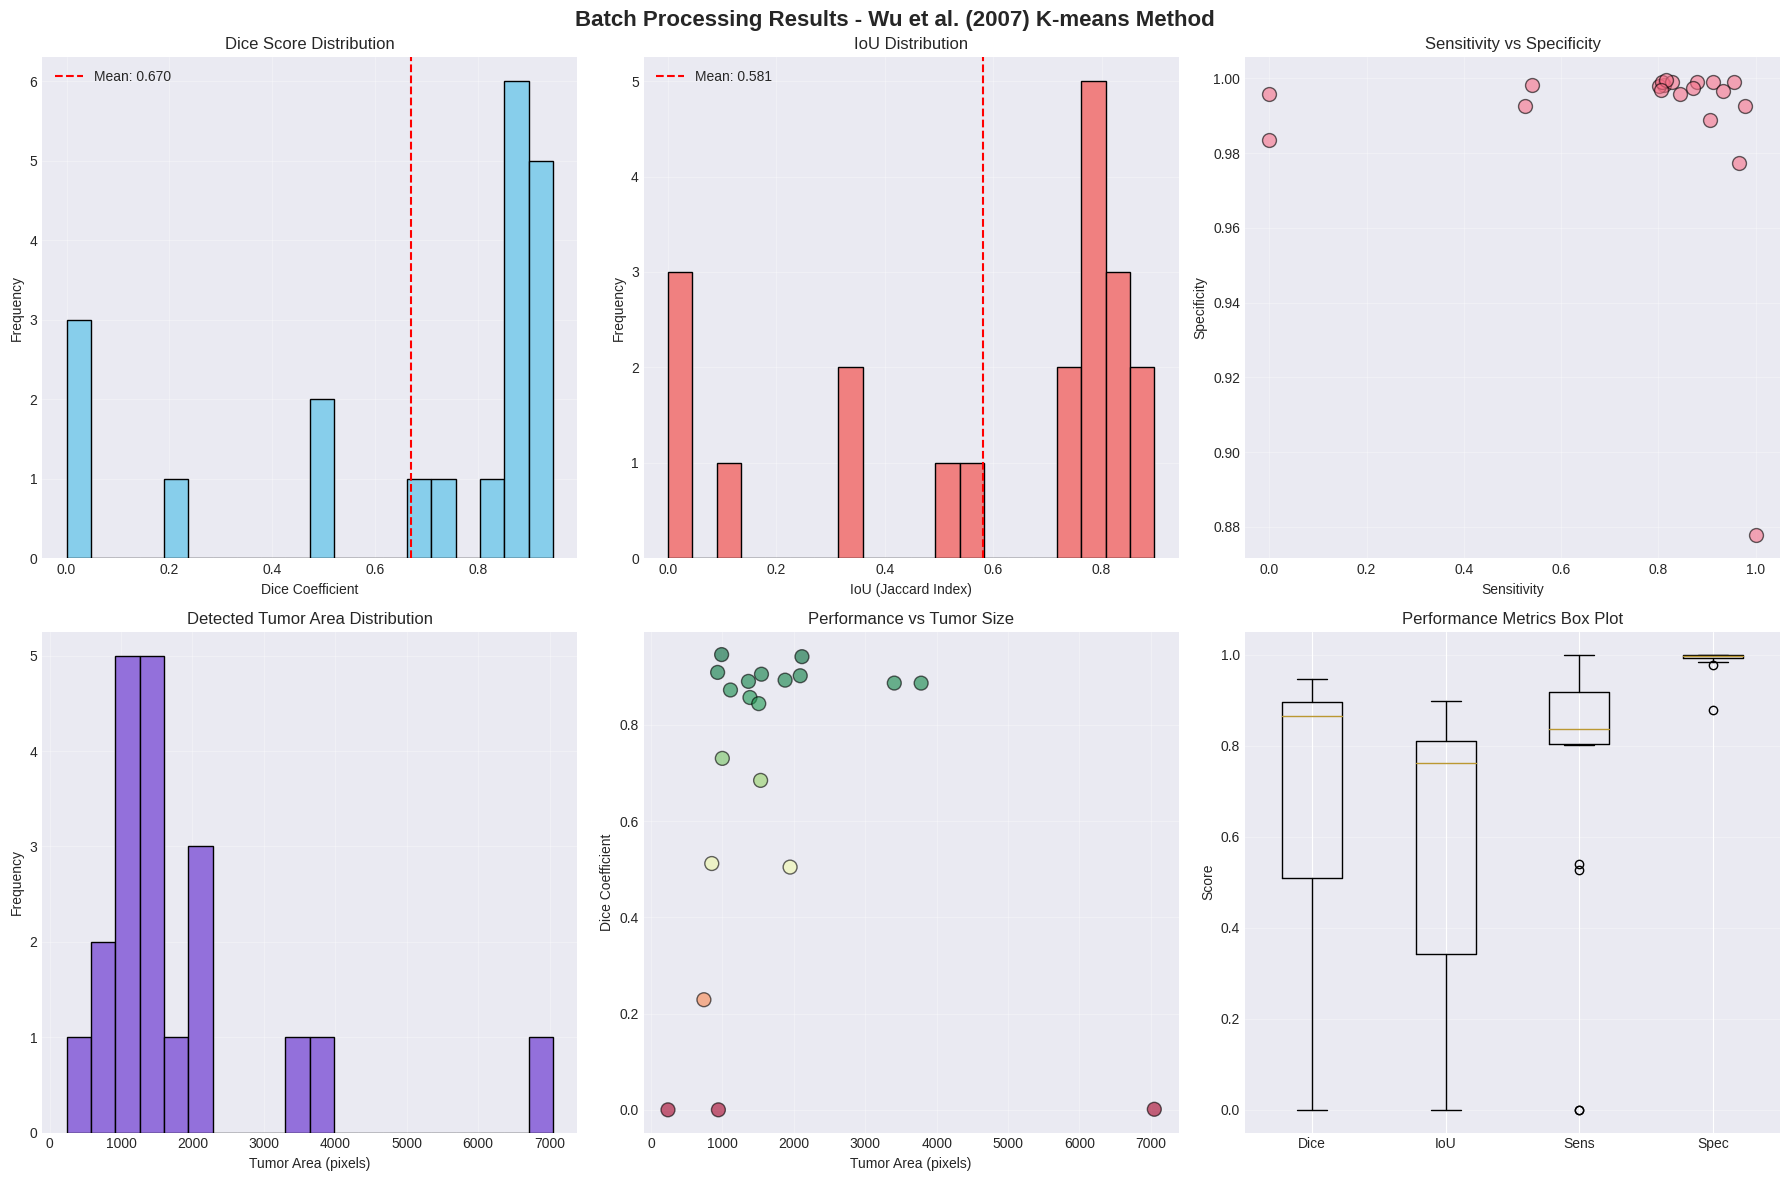


TOP 5 BEST PERFORMING PATIENTS (Highest Dice Score)


,patient_id,dice,iou,tumor_area
10,BraTS20_Training_011,0.945918,0.897386,989
5,BraTS20_Training_006,0.941608,0.889658,2114
13,BraTS20_Training_014,0.908903,0.833017,933
15,BraTS20_Training_016,0.905158,0.826748,1547
16,BraTS20_Training_017,0.901961,0.821429,2090



TOP 5 WORST PERFORMING PATIENTS (Lowest Dice Score)


,patient_id,dice,iou,tumor_area
4,BraTS20_Training_005,0.000000,0.000000,944
6,BraTS20_Training_007,0.000000,0.000000,238
7,BraTS20_Training_008,0.001134,0.000568,7048
18,BraTS20_Training_019,0.228774,0.129161,741
2,BraTS20_Training_003,0.504361,0.337221,1948


In [12]:
# ============================================================================
# CELL 10: Statistical Analysis & Visualization
# ============================================================================
# Filter successful results
successful = summary_df[summary_df['status'] == 'success'].copy()

if len(successful) > 0 and 'dice' in successful.columns:
    # Summary statistics
    print("\n" + "="*70)
    print("STATISTICAL SUMMARY")
    print("="*70)
    print(successful[['tumor_area', 'dice', 'iou', 'sensitivity', 'specificity']].describe())
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Batch Processing Results - Wu et al. (2007) K-means Method', 
                 fontsize=16, fontweight='bold')
    
    # Dice score distribution
    axes[0, 0].hist(successful['dice'], bins=20, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(successful['dice'].mean(), color='red', linestyle='--', 
                      label=f'Mean: {successful["dice"].mean():.3f}')
    axes[0, 0].set_xlabel('Dice Coefficient')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Dice Score Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # IoU distribution
    axes[0, 1].hist(successful['iou'], bins=20, color='lightcoral', edgecolor='black')
    axes[0, 1].axvline(successful['iou'].mean(), color='red', linestyle='--',
                      label=f'Mean: {successful["iou"].mean():.3f}')
    axes[0, 1].set_xlabel('IoU (Jaccard Index)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('IoU Distribution')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Sensitivity vs Specificity
    axes[0, 2].scatter(successful['sensitivity'], successful['specificity'], 
                      alpha=0.6, s=100, edgecolors='black')
    axes[0, 2].set_xlabel('Sensitivity')
    axes[0, 2].set_ylabel('Specificity')
    axes[0, 2].set_title('Sensitivity vs Specificity')
    axes[0, 2].grid(True, alpha=0.3)
    
    # Tumor area distribution
    axes[1, 0].hist(successful['tumor_area'], bins=20, color='mediumpurple', edgecolor='black')
    axes[1, 0].set_xlabel('Tumor Area (pixels)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Detected Tumor Area Distribution')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Dice vs Tumor Area
    axes[1, 1].scatter(successful['tumor_area'], successful['dice'],
                      alpha=0.6, s=100, c=successful['dice'], cmap='RdYlGn',
                      edgecolors='black')
    axes[1, 1].set_xlabel('Tumor Area (pixels)')
    axes[1, 1].set_ylabel('Dice Coefficient')
    axes[1, 1].set_title('Performance vs Tumor Size')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Box plot of metrics
    metrics_data = successful[['dice', 'iou', 'sensitivity', 'specificity']]
    axes[1, 2].boxplot([metrics_data[col].dropna() for col in metrics_data.columns],
                       labels=['Dice', 'IoU', 'Sens', 'Spec'])
    axes[1, 2].set_ylabel('Score')
    axes[1, 2].set_title('Performance Metrics Box Plot')
    axes[1, 2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print best and worst cases
    print("\n" + "="*70)
    print("TOP 5 BEST PERFORMING PATIENTS (Highest Dice Score)")
    print("="*70)
    display(successful.nlargest(5, 'dice')[['patient_id', 'dice', 'iou', 'tumor_area']])
    
    print("\n" + "="*70)
    print("TOP 5 WORST PERFORMING PATIENTS (Lowest Dice Score)")
    print("="*70)
    display(successful.nsmallest(5, 'dice')[['patient_id', 'dice', 'iou', 'tumor_area']])